C:\Users\tsift\AppData\Local\Temp\ipykernel_14544\1216008151.py:18: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])


Homes per residents group:
 res_group
0     4
1    49
2    95
3    53
4    44
5     9
Name: home_id, dtype: int64


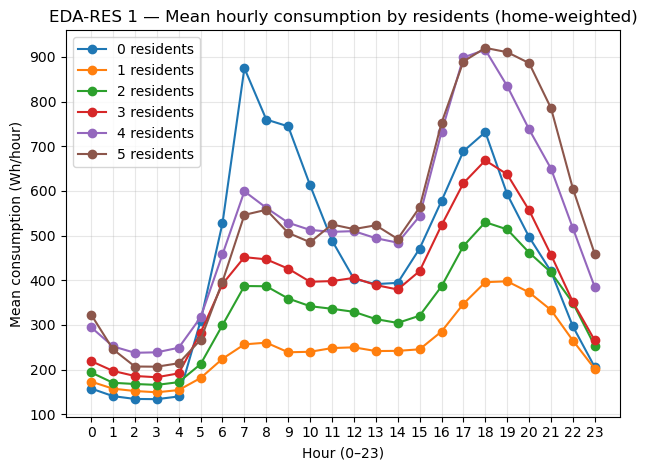

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_residents_floorarea\EDA_RES_01_mean_consumption_by_hour_weighted.png


C:\Users\tsift\AppData\Local\Temp\ipykernel_14544\1216008151.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


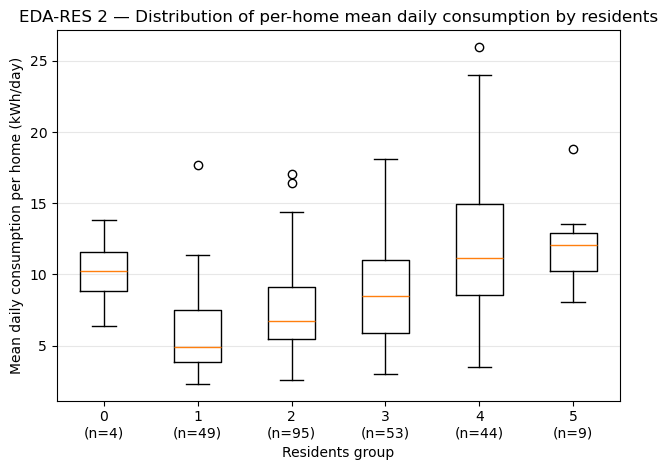

Saved: C:\IDEAL_Programming\processed\plots\eda_new\by_residents_floorarea\EDA_RES_02_mean_daily_kWh_boxplot_showfliers.png

Plots saved to: C:\IDEAL_Programming\processed\plots\eda_new\by_residents_floorarea


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Paths
# =========================
BASE_DIR = Path("C:/IDEAL_Programming")
DATA_PATH = BASE_DIR / "processed" / "final" / "IDEAL_final_hourly_dataset.csv"

# NEW folder
PLOTS_DIR = BASE_DIR / "processed" / "plots" / "eda_new" / "by_residents"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Load
# =========================
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date

need = ["home_id", "timestamp", "consumption_Wh", "residents"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# =========================
# Residents cleaning + grouping
# =========================
df_res = df[df["residents"].notna()].copy()
df_res["residents"] = pd.to_numeric(df_res["residents"], errors="coerce")
df_res = df_res[df_res["residents"].notna()].copy()
df_res["residents"] = df_res["residents"].astype(int)

# group rare values: 6+
def group_res(x: int) -> str:
    if x >= 6:
        return "6+"
    return str(x)

df_res["res_group"] = df_res["residents"].apply(group_res)

# sanity: homes per group
homes_per_group = df_res.groupby("res_group")["home_id"].nunique().sort_index()
print("Homes per residents group:\n", homes_per_group)

def save_show(name: str):
    out = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

# ==========================================================
# Plot 1: Mean hourly consumption by residents group (home-weighted)
# ==========================================================
plt.figure()

order = [str(i) for i in range(0, 6)] + ["6+"]
order = [g for g in order if g in df_res["res_group"].unique()]

for rg in order:
    g = df_res[df_res["res_group"] == rg]

    hw = (
        g.groupby(["home_id", "hour"])["consumption_Wh"].mean()
         .reset_index()
         .groupby("hour")["consumption_Wh"].mean()
         .sort_index()
    )

    plt.plot(hw.index, hw.values, marker="o", label=f"{rg} residents")

plt.xlabel("Hour (0–23)")
plt.ylabel("Mean consumption (Wh/hour)")
plt.title("EDA-RES 1 — Mean hourly consumption by residents (home-weighted)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_RES_01_mean_consumption_by_hour_weighted.png")

# ==========================================================
# Plot 2: Per-home mean daily consumption by residents group (kWh/day)
# ==========================================================
daily = (
    df_res.groupby(["home_id", "res_group", "date"])["consumption_Wh"]
          .sum()
          .reset_index()
)

mean_daily = (
    daily.groupby(["home_id", "res_group"])["consumption_Wh"]
         .mean()
         .reset_index()
)

mean_daily["mean_daily_kWh"] = mean_daily["consumption_Wh"] / 1000.0

# groups for boxplot
groups = [mean_daily.loc[mean_daily["res_group"] == rg, "mean_daily_kWh"].values for rg in order]
labels = [f"{rg}\n(n={homes_per_group.get(rg, 0)})" for rg in order]

plt.figure()
plt.boxplot(groups, labels=labels, showfliers=True)
plt.xlabel("Residents group")
plt.ylabel("Mean daily consumption per home (kWh/day)")
plt.title("EDA-RES 2 — Distribution of per-home mean daily consumption by residents")
plt.grid(True, axis="y", alpha=0.3)
save_show("EDA_RES_02_mean_daily_kWh_boxplot_showfliers.png")

print("\nPlots saved to:", PLOTS_DIR)
